# Nexus V: Arquitectura Cognitiva


## 1. El concepto "Nexus" (El Nexo)

En ingeniería de sistemas, un *nexus* es el punto central donde convergen diferentes conexiones. Este proyecto materializa ese concepto:

- Conecta el LLM con el mundo real a través del *tool calling* (Módulo 4).
- Conecta el pasado con el presente uniendo la memoria de largo plazo (LTM) con la de corto plazo (STM).
- Conecta datos no estructurados (PDFs, manuales) con la lógica de razonamiento del agente.

## 2. El número "V" (Cinco en Romano)

Representa la pentamodalidad de la arquitectura. Cada módulo es un pilar indispensable para que el sistema sea considerado una arquitectura cognitiva completa:

- **Módulo I (STM):** La capacidad de mantener una conversación fluida (*conciencia inmediata*).
- **Módulo II (LTM):** La biblioteca de conocimientos persistentes (*sabiduría acumulada*).
- **Módulo III (Compresión):** La habilidad de sintetizar información (*eficiencia cognitiva*).
- **Módulo IV (Herramientas):** La capacidad de actuar y ejecutar (*autonomía funcional*).
- **Módulo V (Orquestación):** El director de orquesta que integra todo en un flujo organizacional (*gobierno y calidad*).

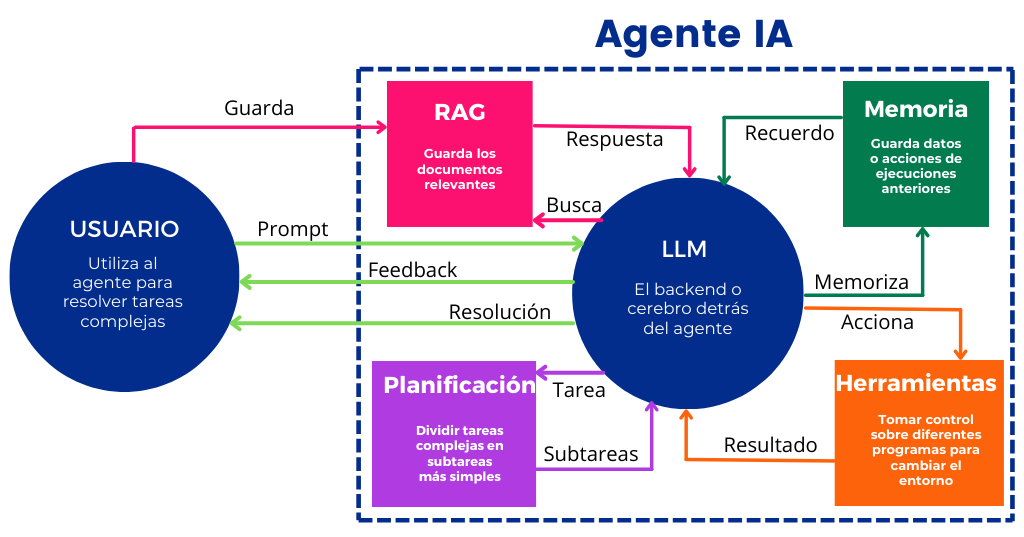

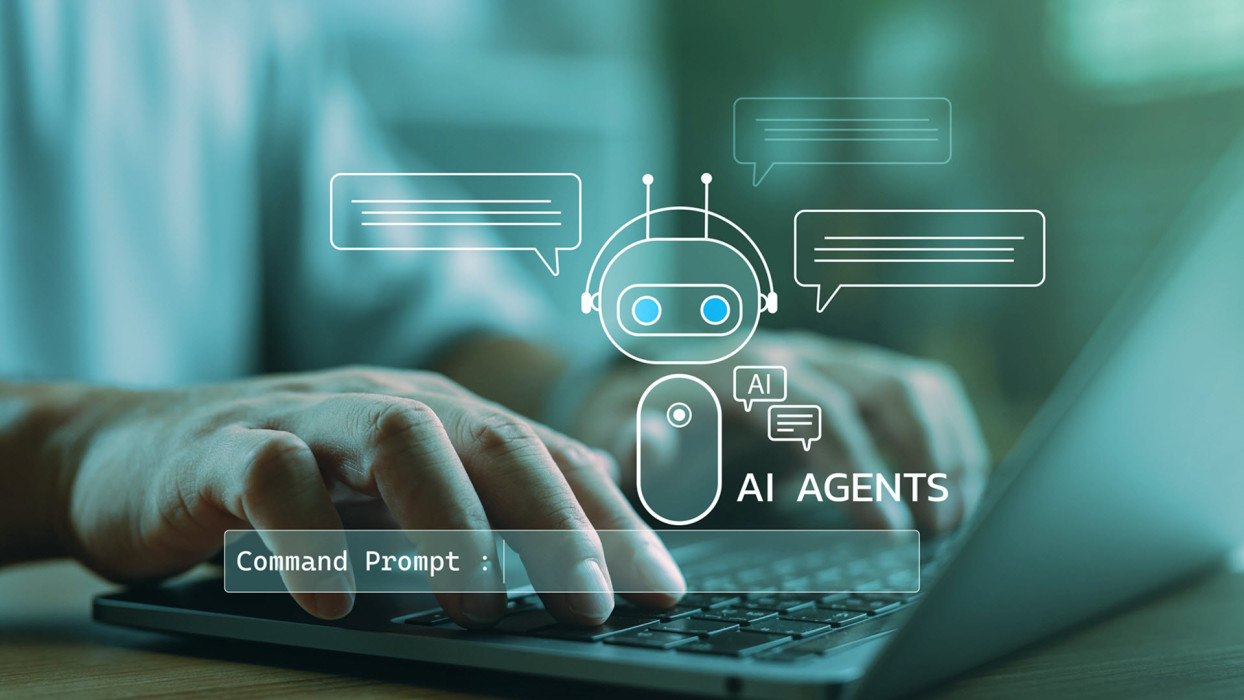

In [ ]:
!pip install -q langsmith langchain-community

In [ ]:
!pip install langchain-core

In [ ]:
!pip install -qU langchain-openai langchain

In [ ]:
import os
import logging
from logging.handlers import RotatingFileHandler
from typing import List, Dict, Any

from google.colab import userdata
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

def setup_production_logging():
    """Configura el sistema de registro siguiendo estandares de Ingenieria de Software."""
    logger = logging.getLogger("NexusV_STM_M1")
    logger.setLevel(logging.INFO)
    formatter = logging.Formatter(
        "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    )

    file_handler = RotatingFileHandler(
        "nexusv_stm_m1.log", maxBytes=1024 * 1024 *5, backupCount=3
    )
    file_handler.setFormatter(formatter)

    if not logger.handlers:
        logger.addHandler(file_handler)
    return logger

logger = setup_production_logging()

class ShortTermCognitiveMemory:
    """
    Gestor de Memoria Episodica para Nexus-V
    Encapsula RunnableWithMessageHistory para proporcionar una interfaz
    """
    def __init__(self, llm, max_messages: int=5):
        self.store = {}
        self.max_messages = max_messages

        self.prompt = ChatPromptTemplate.from_messages([
            ("system", "Eres un asistente tecnico experto en Nexus-V"),
            MessagesPlaceholder(variable_name="chat_history"),
            ("human", "{input}")
        ])

        chain = self.prompt | llm

        self.executor = RunnableWithMessageHistory(
            chain,
            self.get_session_history,
            input_messages_key = "input",
            history_messages_key="chat_history"
        )
        logger.info("Short-Term Memory inicializado con exito")

    def get_session_history(self, session_id: str):
            """
            Patron Factory para recuperar el historial de mensajes de una sesion especifica
            """
            if session_id not in self.store:
                logger.info(f"Iniciando nuevo buffer de memoria: {session_id}")
                self.store[session_id] = InMemoryChatMessageHistory()
            return self.store[session_id]

    def get_messages(self, session_id: str = "default"):
        """Recupera la lista de objetos de mensaje"""
        history = self.get_session_history(session_id)
        return history.messages

    def update_state(self, user_query: str, ai_response:str, session_id: str="default"):
        """
        Sincroniza manualmente el estado si es necesario fuera del flujo directo del ejecutor.
        """
        history = self.get_session_history(session_id)
        history.add_user_message(user_query)
        history.add_ai_message(ai_response)


        if len(history.messages) > self.max_messages * 2:
            history.messages = history.messages[-self.max_messages * 2:]

llm = ChatOpenAI(
    base_url = userdata.get('GITHUB_BASE_URL'),
    api_key=userdata.get('GITHUB_TOKEN'),
    model="gpt-4o",
    temperature=0
)

cognitive_memory = ShortTermCognitiveMemory(llm=llm)

if __name__ == "__main__":
    SESSION = "test_nexus_01"

    resp = cognitive_memory.executor.invoke(
        {"input": "Hola, soy un desarrollador de sistemas"},
        config={"configurable": {"session_id": SESSION}}
    )

    print(f"Mensajes en memoria: {len(cognitive_memory.get_messages(SESSION))}")
    print(f"Respuesta: {resp.content}")



/tmp/ipykernel_82024/3798424926.py:89: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  cognitive_memory = ShortTermCognitiveMemory(llm=llm)
INFO:NexusV_STM_M1:Short-Term Memory inicializado con exito
INFO:NexusV_STM_M1:Iniciando nuevo buffer de memoria: test_nexus_01


Mensajes en memoria: 2
Respuesta: ¡Hola! Es un gusto saludarte. Como desarrollador de sistemas, seguro trabajas con una amplia variedad de herramientas y tecnologías. ¿En qué puedo ayudarte hoy? Si tienes alguna pregunta específica sobre Nexus-V, desarrollo de sistemas, integración de herramientas o cualquier otro tema técnico, no dudes en decírmelo. ¡Estoy aquí para ayudarte! 😊


In [ ]:
!pip install -U langchain-text-splitters faiss-cpu

In [ ]:
from typing import Optional
from datetime import datetime

from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

def setup_semantic_logger():
    """Configura el rastro de auditoria para la base de conocimientos"""
    logger = logging.getLogger("Semantic_Memory_LTM")
    logger.setLevel(logging.INFO)

    formater = logging.Formatter(
        "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    )

    file_handler = RotatingFileHandler(
        "semantic_memory.log", maxBytes=1024 * 1024 * 2, backupCount=2
    )
    file_handler.setFormatter(formater)

    if not logger.handlers:
        logger.addHandler(file_handler)
    return logger

logger = setup_semantic_logger()

class LongTermSemnaticMemory:
    """
    Motor de Recuperacion Aumentada (RAG) para persistencia de datos corporativos
    """

    def __init__(self, index_name: str = "agent_knowledge_base"):
        self.index_name = index_name

        self.embeddings = OpenAIEmbeddings(
            base_url = userdata.get('GITHUB_BASE_URL'),
            api_key=userdata.get('GITHUB_TOKEN'),
            model="text-embedding-3-small"
        )

        self.text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=600,
        chunk_overlap=100,
        length_function=len,
        is_separator_regex=False,
        )

        self.vector_store: Optional[FAISS] = None

        if os.path.exists(self.index_name):
            try:
                self.vector_store = FAISS.load_local(
                    self.index_name,
                    self.embeddings,
                    allow_dangerous_deserialization=True
                )
                logger.info("Indice de memoria cargado desde almacenamiento local")
            except Exception as e:
                logger.error(f"No se pudo cargar el indice existente: {e}")

        logger.info("Modulo de Memoria Semantica (LTM) preparado para operacion")

    def ingest_information(self, raw_text: str, source_id: str = "manual_entry"):
        """
        Procesa, fragmenta y almacena informacion nueva en la base de datos vectorial
        """
        try:
            if not raw_text or len(raw_text) < 15:
               logger.warning(f"Datos insuficientes para ingesta de datos: {source_id}")
               return

            chunks = self.text_splitter.split_text(raw_text)

            documents = [
                Document(
                    page_content=chunk,
                    metadata={
                        "source": source_id,
                        "ingested_at": datetime.now().isoformat(),
                        "module": "LTM-V1"
                        }
                    ) for chunk in chunks
            ]

            if self.vector_store is None:
                self.vector_store = FAISS.from_documents(documents, self.embeddings)
            else:
                self.vector_store.add_documents(documents)

            self.vector_store.save_local(self.index_name)
            logger.info(f"Ingesta exitosa: {len(documents)} nuevos recuerdos añadidos")

        except Exception as e:
            logger.critical(f"Fallo critico en fase de Ingesta: {str(e)}", exc_info=True)

    def search_memories(self, query: str, top_k: int=3) -> List[Document]:
         """
         Recupera los fragmentos de conocimiento mas relevantes para una cosulta dada
         """
         if not self.vector_store:
            logger.warning("Consulta fallida: La memoria esta vacia o no inicializada")
            return []

         try:
             results = self.vector_store.similarity_search(query, k=top_k)
             logger.info(f"Busqueda exitosa. Query: '{query[:40]}...' | Hits: {len(results)}")
             return results
         except Exception as e:
             logger.error(f"Error en fase de recuperacion semantica: {str(e)}", exc_info=True)
             return []

if __name__ == "__main__":
   ltm = LongTermSemnaticMemory()

   politicas = """
   PROTOCOLO DE RED: Todos los sistemas deben operar baje el estandar TLS 1.3.
   REPORTE DE INCIDENCIAS: Usar el canal de Slack #seguridad-ia de inmediato.
   HORARIO DE SOPORTE: Lunes a Viernes, de 08:00 a 18:00 UTC.
   """

   ltm.ingest_information(politicas, source_id="manual_v1_seguridad")

   test_query = "¿Cual es el protocolo de seguridad y donde se reporta?"
   memoria_recuperada = ltm.search_memories(test_query)

   print(f"--- MEMORIA RECUPERADA PARA AGENTE ---")
   for r in memoria_recuperada:
       print(f"-> {r.page_content} (Origen: {r.metadata['source']})")

INFO:Semantic_Memory_LTM:Indice de memoria cargado desde almacenamiento local
INFO:Semantic_Memory_LTM:Modulo de Memoria Semantica (LTM) preparado para operacion
INFO:Semantic_Memory_LTM:Ingesta exitosa: 1 nuevos recuerdos añadidos
INFO:Semantic_Memory_LTM:Busqueda exitosa. Query: '¿Cual es el protocolo de seguridad y don...' | Hits: 3


--- MEMORIA RECUPERADA PARA AGENTE ---
-> PROTOCOLO DE RED: Todos los sistemas deben operar baje el estandar TLS 1.3.
   REPORTE DE INCIDENCIAS: Usar el canal de Slack #seguridad-ia de inmediato.
   HORARIO DE SOPORTE: Lunes a Viernes, de 08:00 a 18:00 UTC. (Origen: manual_v1_seguridad)
-> PROTOCOLO DE RED: Todos los sistemas deben operar baje el estandar TLS 1.3.
   REPORTE DE INCIDENCIAS: Usar el canal de Slack #seguridad-ia de inmediato.
   HORARIO DE SOPORTE: Lunes a Viernes, de 08:00 a 18:00 UTC. (Origen: manual_v1_seguridad)
-> PROTOCOLO DE RED: Todos los sistemas deben operar baje el estandar TLS 1.3.
   REPORTE DE INCIDENCIAS: Usar el canal de Slack #seguridad-ia de inmediato.
   HORARIO DE SOPORTE: Lunes a Viernes, de 08:00 a 18:00 UTC. (Origen: manual_v1_seguridad)


In [ ]:
import logging
from typing import List, Dict
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field

In [ ]:
logger = logging.getLogger("HierarchicalMEMORY")
logger.setLevel(logging.INFO)

handler = logging.FileHandler("memory_compression.log")
handler.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))

if not logger.handlers:
    logger.addHandler(handler)

class CompressedContext(BaseModel):
  """
  Esquema para validar la salida de la compresion semantica
  """

  summary: str = Field(..., description="Resumen ejecutivo del contexto")
  key_facts: List[str] = Field(..., description="Lista de entidades o hechos criticos")

class HierarchicalMemoryManager:
  """
  Gestionar la jerarquia de memoria.
  Transformar la memoria episodica (Modulo 1) en memoria comprimida para optimizar el context window.
  """

  def __init__(self, llm: ChatOpenAI):
      self.llm = llm

      self.compression_prompt = ChatPromptTemplate.from_messages([
         ("system", """Eres un módulo de Compresión Cognitiva.
            Tu tarea es resumir las interacciones anteriores manteniendo:
            1. Identidad de los usuarios.
            2. Decisiones técnicas tomadas.
            3. Pendientes o tareas activas.
            Responde de forma concisa y técnica."""),
            ("human", "Comprime el siguiente historial de conversación: {history}")
        ])
      logger.info("Modulo de Compresion Cognitiva inicializado")

  def compress_history(self, messages: List[Dict]) -> str:
      """
      Aplica un algoritmo de resumen para reducir el consumo de tokens
      """

      try:
          if not messages:
              return "No hay historial previo"

          formatted_history = "\n".join([f"{m.type}: {m.content}" for m in messages])

          chain = self.compression_prompt | self.llm
          summary_response = chain.invoke({"history": formatted_history})

          summary_text = summary_response.content
          logger.info(f"Compresion ejecutada exitosamente. Longitud original: {len(formatted_history)} -> Resumen: {len(summary_text)}")
          return summary_text

      except Exception as e:
          logger.error(f"Error en fase de compresion semantica: {str(e)}")
          return "Error al recuperar el resumen del contexto."

hierarchical_memory = HierarchicalMemoryManager(llm)


INFO:HierarchicalMEMORY:Modulo de Compresion Cognitiva inicializado


In [ ]:
if __name__ == "__main__":

    historial_extenso = [
        HumanMessage(content="Necesito configurar un cluster de Kubernetes en AWS usando Terraform."),
        AIMessage(content="Entendido. Usaremos el módulo oficial de EKS y configuraremos 3 nodos tipo t3.medium."),
        HumanMessage(content="Añade encriptación de discos con KMS y acceso privado para el API Server."),
        AIMessage(content="Perfecto, he actualizado la configuración con el ARN de la llave KMS y habilitado 'endpoint_private_access = true'."),
        HumanMessage(content="¿Cuál era el ARN de la llave que usamos?")
    ]

    contexto_comprimido = hierarchical_memory.compress_history(historial_extenso)

    print("\n=== MEMORIA JERÁRQUICA (RESUMEN COMPRIMIDO) ===")
    print(contexto_comprimido)

INFO:HierarchicalMEMORY:Compresion ejecutada exitosamente. Longitud original: 415 -> Resumen: 306



=== MEMORIA JERÁRQUICA (RESUMEN COMPRIMIDO) ===
El usuario solicitó configurar un clúster de Kubernetes en AWS usando Terraform. Se decidió usar el módulo oficial de EKS con 3 nodos t3.medium, habilitar encriptación de discos con KMS y acceso privado al API Server. El ARN de la llave KMS fue configurado, pero el usuario solicitó confirmación del mismo.


In [ ]:
import os
import logging
from logging.handlers import RotatingFileHandler
from typing import List, Dict, Any, Type
from pydantic import BaseModel, Field

from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, ToolMessage
from google.colab import userdata


In [ ]:
def setup_tools_logger():
    """
    Configura el log para auditoria de ejecucion de herrramientas
    """
    logger = logging.getLogger("Agent_tools")
    logger.setLevel(logging.INFO)
    formatter = logging.Formatter('%(asctime)s | %(levelname)s |TOOL_EXEC | %(message)s')

    file_handler = RotatingFileHandler("agent_tools.log", maxBytes=1024 * 1024 * 2, backupCount=2)
    file_handler.setFormatter(formatter)

    if not logger.handlers:
        logger.addHandler(file_handler)
    return logger

logger = setup_tools_logger()

class CalculatorInput(BaseModel):
    a: float = Field(description="primer numero")
    b: float = Field(description="segundo numero")

@tool("multiplicador_preciso", args_schema=CalculatorInput)
def multiplicar(a: float, b: float) -> float:
    """
    Multiplica dos números con alta precisión.
    Útil para cálculos financieros o de arquitectura de sistemas.
    """
    try:
        resultado = a * b
        logger.info(f"Ejecución exitosa: {a} * {b} = {resultado}")
        return resultado
    except Exception as e:
        logger.error(f"Error en herramienta multiplicar: {str(e)}")
        return f"Error en el cálculo: {str(e)}"

llm = ChatOpenAI(
    base_url = userdata.get('GITHUB_BASE_URL'),
    api_key=userdata.get('GITHUB_TOKEN'),
    model="gpt-4o",
    temperature=0
    )

tools = [multiplicar]
llm_with_tools = llm.bind_tools(tools)

def ejecutar_paso_agente(query: str):
    """
    Ciclo de razonamiento (Reasoning Step) de un agente
    """
    logger.info(f"Iniciando ciclo de razonamiento para: {query}")


    msg = llm_with_tools.invoke([HumanMessage(content=query)])


    if msg.tool_calls:
        for tool_call in msg.tool_calls:
            logger.info(f"El agente decidio usar la herramienta: {tool_call['name']}")

            selected_tool = {"multiplicador_preciso": multiplicar}[tool_call["name"]]

            tool_output = selected_tool.invoke(tool_call)

            print(f"--- AGENTE USANDO HERRAMIENTA ---")
            print(f"Acción: {tool_call['name']} | Argumentos: {tool_call['args']}")
            print(f"Resultado de la herramienta: {tool_output}")

            final_response = llm.invoke([
                HumanMessage(content=query),
                msg,
                ToolMessage(tool_output=str(tool_output), tool_call_id=tool_call["id"])
            ])
            return final_response.content

    return msg.content

if __name__ == "__main__":
   pregunta = "¿Cuanto es 1543.22 multiplicado por 0.13 para el calculo de impuestos?"
   respuesta_final = ejecutar_paso_agente(pregunta)
   print(f"\n--- RESPUESTA FINAL ---")
   print(respuesta_final)

INFO:Agent_tools:Iniciando ciclo de razonamiento para: ¿Cuanto es 1543.22 multiplicado por 0.13 para el calculo de impuestos?
INFO:Agent_tools:El agente decidio usar la herramienta: multiplicador_preciso
INFO:Agent_tools:Ejecución exitosa: 1543.22 * 0.13 = 200.61860000000001


--- AGENTE USANDO HERRAMIENTA ---
Acción: multiplicador_preciso | Argumentos: {'a': 1543.22, 'b': 0.13}
Resultado de la herramienta: content='200.61860000000001' name='multiplicador_preciso' tool_call_id='call_3rlq2M103ax46I0bdqAGNgW0'

--- RESPUESTA FINAL ---
El resultado de multiplicar 1543.22 por 0.13 es **200.6186**. Este sería el cálculo del impuesto.


In [ ]:
import logging
import json
from datetime import datetime
from typing import Dict, Any

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from google.colab import userdata

In [ ]:
def setup_org_logger():
    """
    Establece el log de audioria para la continuidad de tareas organizacionales
    """
    logger = logging.getLogger("Organizational_Agent")
    logger.setLevel(logging.INFO)

    handler = logging.FileHandler("organizational_agent.log")
    handler.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | SESSION_ID: %(name)s | %(message)s'))

    if not logger.handlers:
        logger.addHandler(handler)
    return logger

logger = setup_org_logger()

In [ ]:
class OrganizationalAgent:
    """
    Capa de Inteligencia Central del proyecto Nexus-V.
    Unifica:
    - Memoria Episódica (M1): Historial inmediato.
    - Memoria Semántica (M2): Conocimiento corporativo persistente.
    - Compresión Jerárquica (M3): Gestión de contextos masivos.
    - Tool Calling (M4): Ejecución de acciones externas.
    """

    def __init__(self, session_id: str, stm_manager, ltm_manager, hierarchical_manager, llm):
        self.session_id = session_id
        self.stm = stm_manager
        self.ltm = ltm_manager
        self.compresor = hierarchical_manager
        self.llm = llm
        logger.info(f"Sistema Nexus-V inicializado. Sesión activa: {session_id}")

    def run_workflow(self, user_input: str):
        """
        Ciclo Cognitivo de Producción:
        Retrieval -> Context Consolidation -> Reasoning -> Action -> Persistence.
        """
        try:

            recuerdos = self.ltm.search_memories(user_input, top_k=2)
            contexto_semantico = "\n".join([r.page_content for r in recuerdos])


            historial_reciente = self.stm.get_messages()


            if len(historial_reciente) > 5:
                prompt_historial = self.compresor.compress_history(historial_reciente)
                logger.info(f"Optimización de contexto: Historial comprimido para {self.session_id}")
            else:
                prompt_historial = str(historial_reciente)


            prompt_template = ChatPromptTemplate.from_messages([
                ("system", f"""Eres un Agente Organizacional de Nexus-V.
                RECURSOS SEMÁNTICOS (LTM): {contexto_semantico}
                CONTEXTO EPISÓDICO: {prompt_historial}
                Instrucción: Responde basándote estrictamente en los recursos proporcionados."""),
                ("human", "{input}")
            ])


            chain = prompt_template | self.llm
            response = chain.invoke({"input": user_input})


            self.stm.update_state(user_input, response.content)


            checkpoint = {
                "session": self.session_id,
                "timestamp": datetime.now().isoformat(),
                "token_management": "Compressed" if len(historial_reciente) > 5 else "Raw",
                "status": "SUCCESS"
            }
            logger.info(f"CHECKPOINT: {json.dumps(checkpoint)}")

            return response.content

        except Exception as e:

            logger.critical(f"Fallo en flujo Nexus-V: {str(e)}", exc_info=True)
            return "ERROR: El sistema ha entrado en modo de preservación de estado por una anomalía de memoria."




agente_final = OrganizationalAgent(
    session_id="NEXUS-V-PROD-01",
    stm_manager=cognitive_memory,
    ltm_manager=ltm,
    hierarchical_manager=hierarchical_memory,
    llm=llm
)

if __name__ == "__main__":

    pregunta = "¿A qué canal debo reportar una brecha de seguridad?"
    resultado = agente_final.run_workflow(pregunta)

    print(f"\n--- [SALIDA DE AGENTE ORGANIZACIONAL NEXUS-V] ---")
    print(f"Respuesta: {resultado}")


    print("\n--- [ESTADO DE LOGS DE ARQUITECTURA] ---")

INFO:Organizational_Agent:Sistema Nexus-V inicializado. Sesión activa: NEXUS-V-PROD-01
INFO:Organizational_Agent:Busqueda exitosa. Query: '¿A qué canal debo reportar una brecha de...' | Hits: 2
INFO:Organizational_Agent:Iniciando nuevo buffer de memoria: default
INFO:Organizational_Agent:CHECKPOINT: {"session": "NEXUS-V-PROD-01", "timestamp": "2026-05-14T22:00:30.568405", "token_management": "Raw", "status": "SUCCESS"}



--- [SALIDA DE AGENTE ORGANIZACIONAL NEXUS-V] ---
Respuesta: Debes reportar una brecha de seguridad al canal de Slack **#seguridad-ia** de inmediato.

--- [ESTADO DE LOGS DE ARQUITECTURA] ---


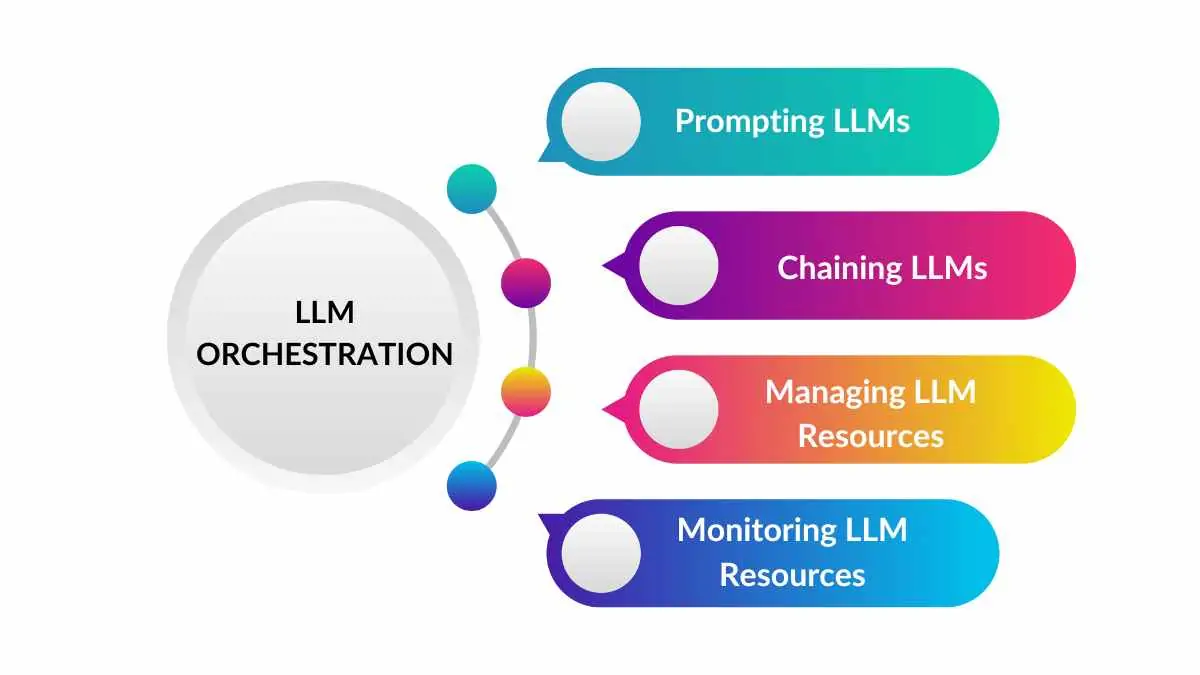

# El Cerebro Estratégico en Salud – De la Reacción a la Planificación Preventiva

## El Escenario: El Agente "Nexus-Health"

Imagina que **Nexus-V** es el núcleo de un sistema de gestión de pacientes en una clínica de alta complejidad.

El agente recibe la siguiente solicitud de una enfermera:

> "El paciente en la cama 402 presenta una baja súbita de presión.  
> Revisa sus antecedentes y sugiere un protocolo de estabilización mientras llega el médico."

---

## Diferencias en Estrategias de Orquestación (Contexto Médico)

### Ejecución Secuencial (Riesgosa)

El agente busca en el PDF del manual de protocolos, luego en el historial, y finalmente responde.

Si el manual es muy extenso, el agente pierde tiempo valioso procesando información irrelevante antes de descubrir que el paciente es alérgico a un medicamento común de estabilización.

---

### Ejecución Basada en Objetivos (Planificación Nexus)

El agente reconoce que el objetivo es:

**"Estabilización Segura"**

Antes de actuar, crea un plan:

1. **Paso 1 ($M_1$ - STM):**  
   Capturar signos vitales actuales del mensaje.

2. **Paso 2 ($M_2$ - LTM):**  
   Consultar *Alergias* y *Medicamentos Actuales* en la ficha clínica  
   (**Prioridad Máxima**).

3. **Paso 3 ($M_4$ - Herramientas):**  
   Acceder a la base de datos de protocolos médicos para filtrar solo los que no interactúen con sus alergias.

4. **Paso 4 ($M_5$ - Orquestación):**  
   Generar una alerta priorizada.

In [ ]:
import logging
import json
from datetime import datetime
from typing import Dict, Any, List, Literal, Optional
from pydantic import BaseModel, Field

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate


def setup_health_logger():
    """Configura el registro de eventos para cumplimiento normativo y trazabilidad."""

    logger = logging.getLogger("Nexus_V_Orchestrator")
    logger.setLevel(logging.INFO)

    handler = logging.FileHandler("nexus_audit_system.log")

    handler.setFormatter(
        logging.Formatter(
            '%(asctime)s | %(levelname)s | SESSION: %(name)s | %(message)s'
        )
    )

    if not logger.handlers:
        logger.addHandler(handler)

    return logger


logger = setup_health_logger()


class MedicalStep(BaseModel):
    """Define una unidad de tarea mínima dentro de la orquestación."""

    id: int
    module: Literal["M1_STM", "M2_LTM", "M4_Tools"]
    action: str = Field(description="Tarea técnica a ejecutar")
    is_critical: bool = Field(
        default=True,
        description="Si falla, detiene el flujo"
    )


class HealthExecutionPlan(BaseModel):
    """Estructura del pensamiento previo generado por el agente."""

    triage_priority: int = Field(
        ge=1,
        le=5,
        description="Prioridad: 1 es Urgencia Vital"
    )

    plan_rationale: str = Field(
        description="Justificación lógica del plan"
    )

    steps: List[MedicalStep]

    allow_short_circuit: bool = Field(
        default=False,
        description="Permite saltar pasos en Triage 1"
    )


class OrganizationalAgent:

    def __init__(
        self,
        session_id: str,
        stm_manager,
        ltm_manager,
        hierarchical_manager,
        llm
    ):
        """Inyecta las dependencias de los 5 pilares de la arquitectura cognitiva."""

        self.session_id = session_id
        self.stm = stm_manager
        self.ltm = ltm_manager
        self.compresor = hierarchical_manager
        self.llm = llm

        logger.info(
            f"Instancia Nexus-V Salud iniciada. Sesión: {session_id}"
        )

    def _generate_plan(self, user_input: str) -> HealthExecutionPlan:
        """FASE DE PLANIFICACIÓN."""

        planner_prompt = f"""
        Eres el Jefe de Estrategia de Nexus-V.
        Analiza la petición: '{user_input}'.

        Diseña un plan de ejecución médica basado en los módulos disponibles.

        Si detectas riesgo de vida inmediato:
        - allow_short_circuit=True
        - triage=1
        """

        return self.llm.with_structured_output(
            HealthExecutionPlan
        ).invoke(planner_prompt)

    def _generate_contingency_plan(
        self,
        query: str,
        finding: str
    ) -> HealthExecutionPlan:
        """FASE DE RE-PLANIFICACIÓN."""

        logger.warning(
            f"Generando plan de contingencia por hallazgo: {finding}"
        )

        prompt = f"""
        Petición original: {query}

        Hallazgo crítico:
        {finding}

        Re-planifica por seguridad.
        """

        return self.llm.with_structured_output(
            HealthExecutionPlan
        ).invoke(prompt)

    def run_workflow(self, user_input: str):

        try:

            plan = self._generate_plan(user_input)

            if (
                plan.triage_priority == 1
                and plan.allow_short_circuit
            ):

                logger.warning(
                    "TRIAGE 1: Protocolo de emergencia."
                )

                plan.steps = [
                    MedicalStep(
                        id=99,
                        module="M4_Tools",
                        action="Protocolo_Urgencia_Vital",
                        is_critical=True
                    )
                ]

            contexto_acumulado = {}

            i = 0

            while i < len(plan.steps):

                step = plan.steps[i]

                logger.info(
                    f"Ejecutando Paso {step.id}: {step.module}"
                )

                try:

                    if step.module == "M1_STM":

                        contexto_acumulado["episodico"] = str(
                            self.stm.get_messages()
                        )

                    elif step.module == "M2_LTM":

                        recuerdos = self.ltm.search_memories(
                            user_input,
                            top_k=2
                        )

                        contenido = "\n".join(
                            [r.page_content for r in recuerdos]
                        )

                        contexto_acumulado["historial"] = contenido

                        if (
                            "ALERGIA" in contenido.upper()
                            or "CONTRAINDICACIÓN" in contenido.upper()
                        ):

                            plan = self._generate_contingency_plan(
                                user_input,
                                contenido
                            )

                            i = 0
                            continue

                    elif step.module == "M4_Tools":

                        contexto_acumulado["accion_herramienta"] = (
                            f"Ejecutado: {step.action}"
                        )

                except Exception as e:

                    logger.error(
                        f"Error en {step.module}: {e}"
                    )

                    if step.is_critical:

                        return (
                            "DETENCIÓN DE SEGURIDAD: "
                            "Fallo en paso crítico. "
                            "Requiere Médico Humano."
                        )

                i += 1

            contexto_sanitizado = json.dumps(
                contexto_acumulado,
                indent=2,
                ensure_ascii=False
            )

            prompt_final = ChatPromptTemplate.from_messages([
                (
                    "system",
                    """
                    Eres Nexus-V Salud.

                    Sintetiza una respuesta profesional y segura.

                    PRIORIDAD TRIAGE:
                    {triage}

                    RAZONAMIENTO APLICADO:
                    {razonamiento}

                    DATOS OBTENIDOS:
                    {datos}
                    """
                ),
                ("human", "{consulta}")
            ])

            chain = prompt_final | self.llm

            response = chain.invoke({
                "triage": plan.triage_priority,
                "razonamiento": plan.plan_rationale,
                "datos": contexto_sanitizado,
                "consulta": user_input
            })

            self.stm.update_state(
                user_input,
                response.content
            )

            return response.content

        except Exception as e:

            logger.critical(
                f"Fallo masivo: {e}",
                exc_info=True
            )

            return (
                "ERROR DE GOBIERNO: "
                "Sistema en modo seguro. "
                "Por favor, proceda manualmente."
            )


agente_final = OrganizationalAgent(
    session_id="NEXUS-V-PROD-2026",
    stm_manager=cognitive_memory,
    ltm_manager=ltm,
    hierarchical_manager=hierarchical_memory,
    llm=llm
)


if __name__ == "__main__":

    resultado = agente_final.run_workflow(
        "El paciente tiene fiebre, ¿puedo darle penicilina?"
    )

    print(
        f"\n--- [NEXUS-V RESULTADO FINAL] ---\n{resultado}"
    )

INFO:Nexus_V_Orchestrator:Instancia Nexus-V Salud iniciada. Sesión: NEXUS-V-PROD-2026
INFO:Nexus_V_Orchestrator:Ejecutando Paso 1: M1_STM
INFO:Nexus_V_Orchestrator:Ejecutando Paso 2: M1_STM
INFO:Nexus_V_Orchestrator:Ejecutando Paso 3: M4_Tools
INFO:Nexus_V_Orchestrator:Ejecutando Paso 4: M2_LTM
INFO:Nexus_V_Orchestrator:Busqueda exitosa. Query: 'El paciente tiene fiebre, ¿puedo darle p...' | Hits: 2



--- [NEXUS-V RESULTADO FINAL] ---
La administración de penicilina debe ser evaluada cuidadosamente. Antes de proceder, es fundamental confirmar si el paciente tiene antecedentes de alergia a la penicilina, ya que esta puede causar reacciones graves en personas alérgicas. Si no se dispone de esta información, se debe realizar una prueba de alergia bajo supervisión médica.

Además, la fiebre puede ser causada por diversas condiciones, y la penicilina solo es efectiva contra infecciones bacterianas específicas. Es necesario identificar la causa de la fiebre mediante una evaluación médica adecuada antes de iniciar cualquier tratamiento antibiótico.

Recomendación: Consulta con un médico para determinar la causa de la fiebre y confirmar si la penicilina es el tratamiento adecuado. No administres medicamentos sin una evaluación profesional.
